#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Import Multi-task ElasticNet

In [3]:
import joblib

model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/ElasticNet.pkl')

In [4]:
model_features = model_1.feature_names_in_
model_features

array(['GPT', 'GUSB', 'NDUFA7', ..., 'UGT2B11', 'NAA60', 'MTAP'],
      dtype=object)

In [5]:
import pickle

with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/y_train_features.pkl', 'rb') as f:
    y_train_features_loaded = pickle.load(f)

print(y_train_features_loaded)

Index(['2-aminoadipate', '3-phosphoglycerate', 'alpha-glycerophosphate',
       '4-pyridoxate', 'aconitate', 'adenine', 'adipate',
       'alpha-ketoglutarate', 'AMP', 'citrate',
       ...
       'C56:8 TAG', 'C56:7 TAG', 'C56:6 TAG', 'C56:5 TAG', 'C56:4 TAG',
       'C56:3 TAG', 'C56:2 TAG', 'C58:8 TAG', 'C58:7 TAG', 'C58:6 TAG'],
      dtype='object', length=225)


#Import Random forest regressor

In [6]:
model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/Random Forest Regressor.pkl')

#Import ensemble

In [7]:
final_estimator = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/Ensemble.pkl')

#RNA-Seq data

In [8]:
counts_mcf7 = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF7_isogenics_RNA_seq/RawCounts.csv')
counts_mcf7 = counts_mcf7.rename(columns = {'Gene_ID' : 'gene_id'})

counts_mcf7 = counts_mcf7[['gene_id', 'eV_DM1', 'eV_DM2', 'eV_DM3',
                           'PI3K_WT_DM1', 'PI3K_WT_DM2', 'PI3K_WT_DM3']]

counts_mcf7 = counts_mcf7.rename(columns = {'eV_DM1' : 'MCF7_E545K_1',
                                            'eV_DM2' : 'MCF7_E545K_2',
                                            'eV_DM3' : 'MCF7_E545K_3',
                                            'PI3K_WT_DM1' : 'MCF7_WT_1',
                                            'PI3K_WT_DM2' : 'MCF7_WT_2',
                                            'PI3K_WT_DM3' : 'MCF7_WT_3'})

counts_mcf7 = counts_mcf7.set_index('gene_id')
counts_mcf7

,MCF7_E545K_1,MCF7_E545K_2,MCF7_E545K_3,MCF7_WT_1,MCF7_WT_2,MCF7_WT_3
gene_id,,,,,,
ENSG00000223972,0,9,3,2,5,10
ENSG00000227232,1407,1327,1275,1152,1341,1502
ENSG00000278267,50,62,18,33,67,87
ENSG00000243485,2,5,2,8,8,6
ENSG00000284332,0,0,0,0,0,0
...,...,...,...,...,...,...
ENSG00000271254,7058,8025,9493,5142,6120,6805
ENSG00000275405,5,3,7,4,8,13
ENSG00000275987,0,0,0,0,4,0


In [9]:
counts_mcf10a = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF10A_PIK3CA_isogenics_RNA_seq_analysis/MCF_PI3K_featureCounts/counts_matrix_filtered_MCF_PI3K.csv')
counts_mcf10a = counts_mcf10a.rename(columns = {'Unnamed: 0' : 'gene_id'})


# #compare by excluding E5_3

counts_mcf10a = counts_mcf10a[['gene_id', 'MCF_WT_1', 'MCF_WT_2', 'MCF_WT_3',
                               'MCF_E5_1', 'MCF_E5_2',
                               'MCF_H10_1', 'MCF_H10_2', 'MCF_H10_3']]


counts_mcf10a = counts_mcf10a.rename(columns = {'MCF_WT_1' : 'MCF10A_WT_1', 'MCF_WT_2' : 'MCF10A_WT_2', 'MCF_WT_3' : 'MCF10A_WT_3',
                                                'MCF_E5_1' : 'MCF10A_E545K_1', 'MCF_E5_2' : 'MCF10A_E545K_2',
                                                'MCF_H10_1' : 'MCF10A_H1047R_1', 'MCF_H10_2' : 'MCF10A_H1047R_2', 'MCF_H10_3' : 'MCF10A_H1047R_3'})
counts_mcf10a = counts_mcf10a.set_index('gene_id')
counts_mcf10a

,MCF10A_WT_1,MCF10A_WT_2,MCF10A_WT_3,MCF10A_E545K_1,MCF10A_E545K_2,MCF10A_H1047R_1,MCF10A_H1047R_2,MCF10A_H1047R_3
gene_id,,,,,,,,
ENSG00000227232,418,506,525,255,329,328,249,372
ENSG00000233750,13,39,25,14,5,17,3,13
ENSG00000268903,8,8,12,9,17,11,27,12
ENSG00000241860,5,22,13,31,19,28,11,19
ENSG00000279457,465,501,370,168,212,339,240,323
...,...,...,...,...,...,...,...,...
ENSG00000182484,81,153,117,59,105,34,31,42
ENSG00000231341,20,22,20,34,24,26,20,20
ENSG00000235001,34,44,72,92,55,77,68,69


#TPM normalization

In [10]:
#TMM normalization with rnanorm
!pip install rnanorm
from rnanorm import TPM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.6/124.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.1/267.1 kB 11.3 MB/s eta 0:00:00


In [11]:
def tpm_normalize(counts):
  counts = counts.T
  norm_counts = TPM(gtf = 'drive/My Drive/Colab Notebooks/Homo_sapiens.GRCh38.113.gtf').fit(counts)
  norm_counts = norm_counts.transform(counts)
  norm_counts = pd.DataFrame(norm_counts)
  norm_counts.columns = counts.columns
  norm_counts.index = counts.index

  return norm_counts

In [12]:
mcf7_tpm = tpm_normalize(counts_mcf7)
mcf10a_tpm = tpm_normalize(counts_mcf10a)

/usr/local/lib/python3.11/dist-packages/rnanorm/methods/within_sample.py:138: UserWarning: X contains 1379 genes that are not in GTF drive/My Drive/Colab Notebooks/Homo_sapiens.GRCh38.113.gtf. This will result in NaN values for missing genes in the output.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/rnanorm/methods/within_sample.py:138: UserWarning: X contains 164 genes that are not in GTF drive/My Drive/Colab Notebooks/Homo_sapiens.GRCh38.113.gtf. This will result in NaN values for missing genes in the output.
  warnings.warn(


In [13]:
mcf7_tpm.head(3)

gene_id,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000284332,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000238009,...,ENSG00000273532,ENSG00000276351,ENSG00000275661,ENSG00000277856,ENSG00000275063,ENSG00000271254,ENSG00000275405,ENSG00000275987,ENSG00000277475,ENSG00000268674
MCF7_E545K_1,0.000000,30.198648,21.778782,0.033986,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,48.707342,0.903023,0.0,0.0,0.0
MCF7_E545K_2,0.419595,28.333248,26.865029,0.084523,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,55.092167,0.538992,0.0,0.0,0.0
MCF7_E545K_3,0.116541,22.683291,6.498881,0.028171,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,54.302364,1.047922,0.0,0.0,0.0


In [14]:
mcf10a_tpm.head(3)

gene_id,ENSG00000227232,ENSG00000233750,ENSG00000268903,ENSG00000241860,ENSG00000279457,ENSG00000228463,ENSG00000236679,ENSG00000236601,ENSG00000237094,ENSG00000250575,...,ENSG00000274791,ENSG00000277150,ENSG00000185973,ENSG00000124333,ENSG00000185203,ENSG00000182484,ENSG00000231341,ENSG00000235001,ENSG00000215414,ENSG00000185275
MCF10A_WT_1,10.088677,0.113587,0.352923,0.011417,11.086477,10.349257,0.692096,2.690787,10.920365,0.806468,...,NaN,23.414492,2.091877,14.443697,1.456343,0.584209,0.779114,0.928231,33.262165,27.824462
MCF10A_WT_2,11.164092,0.311504,0.322623,0.045924,10.919262,34.445009,2.926126,2.112878,9.650034,0.786377,...,NaN,15.446722,1.852706,11.340683,3.007771,1.008764,0.783445,1.098107,37.802592,17.917678
MCF10A_WT_3,12.287037,0.211814,0.513335,0.028786,8.554059,45.795810,6.795028,6.272143,3.000301,0.443144,...,NaN,18.807012,2.268587,16.204256,3.216660,0.818274,0.755494,1.906073,42.975966,34.955572


#Select genes in metabolism

In [15]:
met_genes = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/FBA_metabolic_atlas_models/human_gem_associated_genes.csv')
met_genes

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000198886,MT-ND4
...,...,...
2879,ENSG00000167751,KLK2
2880,ENSG00000129873,CDY2B
2881,ENSG00000182415,CDY2A
2882,ENSG00000172352,CDY1B


In [16]:
def select_met_genes(df):
  met_genes_select = met_genes[met_genes['gene_id'].isin(df.columns)]
  met_genes_select = met_genes_select.gene_id.to_list()
  print('N of metabolism related genes: ' + str(len(met_genes_select)))
  df = df[met_genes_select]
  df = df.T
  df = pd.concat([met_genes.set_index('gene_id'), df], axis = 'columns')
  df = df.set_index('Symbol')
  df.index.name = None
  df = df.T

  return df

In [17]:
mcf7_met = select_met_genes(mcf7_tpm)
mcf10a_met = select_met_genes(mcf10a_tpm)

N of metabolism related genes: 2884
N of metabolism related genes: 2173


In [18]:
mcf7_met.head(3)

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2B,CDY2A,CDY1B,CDY1
MCF7_E545K_1,34493.310622,41953.268546,16042.959405,16042.571568,24442.499110,8039.153966,8620.932950,2442.808849,1811.556581,8677.138592,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
MCF7_E545K_2,34702.983113,43156.748151,18071.999984,16606.980586,27328.453225,9084.207958,8857.501910,2621.436697,1635.167067,8670.716098,...,0.0,0.0,0.050196,0.0,0.0,0.009279,0.0,0.0,0.0,0.0
MCF7_E545K_3,37164.140400,46634.481240,18255.602600,16691.261066,27806.034684,10241.209901,9497.240214,2517.078670,1810.959841,9240.698279,...,0.0,0.0,0.125475,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [19]:
mcf10a_met.head(3)

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2B,CDY2A,CDY1B,CDY1
MCF10A_WT_1,81191.934371,4136.022153,26445.084021,6663.281399,2370.219332,1423.346445,1319.274978,173.370268,381.610229,862.814524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCF10A_WT_2,116934.644288,11382.042072,43101.730088,15083.774097,4936.166461,3618.436862,2537.809752,233.812332,314.490258,1476.895926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCF10A_WT_3,60088.613131,6961.022300,23361.162199,7570.101378,2399.473081,1484.155846,1134.436808,156.726177,427.054916,740.001297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Metabolite prediction

In [20]:
def filter_model_features(df):
  filtered_data = df[model_features]
  return filtered_data

In [21]:
mcf7_met_filtered = filter_model_features(mcf7_met)
mcf10a_met_filtered = filter_model_features(mcf10a_met)

In [22]:
mcf7_met_filtered.head(2)

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
MCF7_E545K_1,3.288628,26.347570,0.595787,26.598550,8.854033,8.851003,156.848130,16.458838,0.336964,0.245279,...,39.450707,0.000000,3.852274,0.270494,0.746701,169.965250,23.057546,0.025133,47.687263,0.024467
MCF7_E545K_2,4.479601,35.413852,0.656186,38.393217,7.886087,8.865004,188.700821,15.199397,0.234646,0.230813,...,28.505405,0.030677,4.136756,0.322903,1.403089,147.946748,31.771949,0.075006,44.732556,0.068962


In [23]:
mcf10a_met_filtered.head(2)

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
MCF10A_WT_1,NaN,23.468126,0.191420,1.192218,2.918397,1.613552,21.391733,2.986417,NaN,NaN,...,20.117217,NaN,NaN,NaN,0.559783,80.605455,0.462696,NaN,6.476509,1.160143
MCF10A_WT_2,NaN,15.908107,0.262479,0.712864,1.984263,0.931592,14.584383,2.886516,NaN,NaN,...,12.457258,NaN,NaN,NaN,0.469079,57.562335,0.390928,NaN,4.308807,0.907536


In [24]:
def predict_metabolites(model, filtered_data):
  pred_metabolites = model.predict(filtered_data)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)
  return pred_metabolites

In [25]:
#Elastic Net predictions
mcf7_pred_elastic = predict_metabolites(model_1, mcf7_met_filtered)
mcf10a_pred_elastic = predict_metabolites(model_1, mcf10a_met_filtered)

#Random forest regressor predictions
mcf7_pred_rf = predict_metabolites(model_2, mcf7_met_filtered)
mcf10a_pred_rf = predict_metabolites(model_2, mcf10a_met_filtered)

In [26]:
#Ensemble predictions

def predict_metabolites_ensemble(model_1, model_2, final_estimator, filtered_data):
  pred_1 = model_1.predict(filtered_data)
  pred_2 = model_2.predict(filtered_data)
  stacked_preds = np.hstack([pred_1, pred_2])
  pred_metabolites = final_estimator.predict(stacked_preds)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)

  return pred_metabolites

mcf7_pred_ensemble = predict_metabolites_ensemble(model_1, model_2, final_estimator, mcf7_met_filtered)
mcf10a_pred_ensemble = predict_metabolites_ensemble(model_1, model_2, final_estimator, mcf10a_met_filtered)

#LCMS data

In [27]:
lcms = pd.read_excel('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/MCF10A_MCF7_LCMS_normalized.xlsx', index_col = 0)
lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,74.880807,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,NaN,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,NaN,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,NaN,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,NaN,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,NaN,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,29.445944,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,NaN,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,NaN,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,30.043648,97927.909452


In [28]:
mcf7_lcms = lcms.iloc[0:10, :]
mcf7_lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,74.880807,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,NaN,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,NaN,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,NaN,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,NaN,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,NaN,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,29.445944,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,NaN,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,NaN,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,30.043648,97927.909452


In [29]:
mcf7_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid'], inplace = True)
mcf7_lcms

<ipython-input-29-b689c9715496>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid'], inplace = True)


,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,12698.019452,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,7951.152785,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,13662.223165,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,12548.159246,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,5677.340657,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,11864.721622,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,7041.213783,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,9338.797941,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,10418.636788,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,8320.337393,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,97927.909452


In [30]:
mcf10a_lcms = lcms.iloc[10:, :]
mcf10a_lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF10A_WT_1,14629.220144,10700.284412,6820.704556,43416.756835,9307.223501,5135.207194,10178.406715,688933.580815,94452.350120,320722.800000,...,682.428777,7.214902e+05,4.273670e+05,1053.811511,35230.154436,94586.316067,2356.945324,2.929557e+05,309.658993,5696.731415
MCF10A_WT_2,6513.793736,1068.481437,22249.883740,79633.371350,22817.427084,2257.518379,65751.837955,734192.279779,146850.058591,14286.426716,...,505.267434,2.233427e+06,1.214628e+06,110.697927,138850.634731,381690.049747,14339.111469,1.617129e+06,54.682911,71239.377982
MCF10A_WT_3,7193.922041,1019.115903,14225.550897,53123.123794,18777.137027,2192.053009,37166.752969,518907.675568,5447.022639,46907.398565,...,307671.338860,1.833821e+06,1.030254e+06,1195.413790,77805.404384,214550.840733,6746.808928,8.549959e+05,45.587326,35240.270626
MCF10A_WT_4,12724.022162,550.086713,19593.572243,87613.676708,20645.986444,3716.041097,31220.221194,605856.343088,12862.088327,50126.885100,...,444885.429586,2.612777e+06,1.446100e+06,NaN,125497.554384,343791.050350,15301.698010,1.416018e+06,77.239268,66038.018827
MCF10A_WT_5,27169.239554,1465.765972,12411.838778,41440.972176,19581.769850,5827.316917,15704.134755,418008.320213,49098.463888,100950.706156,...,3.224237,1.916138e+06,1.100620e+06,491.485797,73104.517111,197703.246049,6501.252448,7.802213e+05,52.849443,38461.917790
MCF10A_E545K_1,16517.819147,3562.870456,16234.026776,36844.123261,9322.103515,2918.172924,4706.800299,489578.071055,60251.586238,283604.618100,...,298425.306956,8.860620e+05,5.284472e+05,968.290052,65243.584892,173375.724458,1648.461631,6.250034e+05,89.225879,32316.531788
MCF10A_E545K_2,15044.508376,2565.517844,20283.072542,61417.296577,14848.408449,2326.238019,12484.151056,433003.594173,56119.965623,298450.187327,...,513743.368536,2.831857e+06,1.614490e+06,NaN,126345.118864,332154.414712,8121.506919,1.439038e+06,NaN,125193.584705
MCF10A_E545K_3,10122.212804,4461.958057,13851.488300,32794.833113,8812.832671,4054.652097,4050.183223,316953.943046,52621.738190,197052.559382,...,278512.687417,9.012521e+05,5.161564e+05,NaN,59699.583664,159258.332892,2451.603091,5.481742e+05,NaN,28393.736865
MCF10A_E545K_4,5970.873512,2137.413080,17125.784696,89673.562328,19621.151341,1777.946370,37589.663702,448479.689863,76455.760497,77291.300719,...,650031.851537,3.036168e+06,1.695152e+06,NaN,143012.237148,383086.254938,13255.630477,1.648200e+06,NaN,268179.945324
MCF10A_E545K_5,8455.979517,3197.384199,19769.686613,71504.329773,15076.797805,4957.971178,13999.120556,318491.919239,61703.475055,59690.604974,...,144.388442,2.903107e+06,1.856564e+06,NaN,151436.501829,409180.131090,7954.692465,1.767400e+06,NaN,187324.381273


In [31]:
mcf10a_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid', 'allantoin', 'cystathionine', 'glycodeoxycholate/glycochenodeoxycholate',
                            'serotonin', 'guanosine'], inplace = True)
mcf10a_lcms

<ipython-input-31-70316a840654>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf10a_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid', 'allantoin', 'cystathionine', 'glycodeoxycholate/glycochenodeoxycholate',


,adenine,xanthine,uracil,uridine,phenylalanine,leucine,methionine,betaine,urate,hypoxanthine,...,NADH,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF10A_WT_1,14629.220144,6820.704556,43416.756835,9307.223501,688933.580815,94452.350120,320722.800000,7.396668e+05,2670.649880,201136.635012,...,8560.412470,NaN,682.428777,7.214902e+05,4.273670e+05,35230.154436,94586.316067,2356.945324,2.929557e+05,5696.731415
MCF10A_WT_2,6513.793736,22249.883740,79633.371350,22817.427084,734192.279779,146850.058591,14286.426716,6.424412e+05,4140.648641,220727.537356,...,16147.377430,5576.458038,505.267434,2.233427e+06,1.214628e+06,138850.634731,381690.049747,14339.111469,1.617129e+06,71239.377982
MCF10A_WT_3,7193.922041,14225.550897,53123.123794,18777.137027,518907.675568,5447.022639,46907.398565,6.716899e+05,269.028617,155284.378159,...,14509.679235,4348.662017,307671.338860,1.833821e+06,1.030254e+06,77805.404384,214550.840733,6746.808928,8.549959e+05,35240.270626
MCF10A_WT_4,12724.022162,19593.572243,87613.676708,20645.986444,605856.343088,12862.088327,50126.885100,9.746034e+05,2602.488865,223425.823669,...,28485.655514,9669.298548,444885.429586,2.612777e+06,1.446100e+06,125497.554384,343791.050350,15301.698010,1.416018e+06,66038.018827
MCF10A_WT_5,27169.239554,12411.838778,41440.972176,19581.769850,418008.320213,49098.463888,100950.706156,7.624719e+05,1922.976733,197711.516917,...,12406.792147,3596.285410,3.224237,1.916138e+06,1.100620e+06,73104.517111,197703.246049,6501.252448,7.802213e+05,38461.917790
MCF10A_E545K_1,16517.819147,16234.026776,36844.123261,9322.103515,489578.071055,60251.586238,283604.618100,7.077172e+05,2334.473448,174670.743455,...,12108.546597,4691.442633,298425.306956,8.860620e+05,5.284472e+05,65243.584892,173375.724458,1648.461631,6.250034e+05,32316.531788
MCF10A_E545K_2,15044.508376,20283.072542,61417.296577,14848.408449,433003.594173,56119.965623,298450.187327,1.044014e+06,2960.666570,232915.529497,...,29061.019228,8669.259723,513743.368536,2.831857e+06,1.614490e+06,126345.118864,332154.414712,8121.506919,1.439038e+06,125193.584705
MCF10A_E545K_3,10122.212804,13851.488300,32794.833113,8812.832671,316953.943046,52621.738190,197052.559382,6.340232e+05,2001.310817,185970.602649,...,14917.208389,7603.257395,278512.687417,9.012521e+05,5.161564e+05,59699.583664,159258.332892,2451.603091,5.481742e+05,28393.736865
MCF10A_E545K_4,5970.873512,17125.784696,89673.562328,19621.151341,448479.689863,76455.760497,77291.300719,9.078720e+05,6198.223676,266750.211642,...,32671.845128,9694.158012,650031.851537,3.036168e+06,1.695152e+06,143012.237148,383086.254938,13255.630477,1.648200e+06,268179.945324
MCF10A_E545K_5,8455.979517,19769.686613,71504.329773,15076.797805,318491.919239,61703.475055,59690.604974,7.905210e+05,3494.623409,236405.344696,...,31346.889393,9619.337820,144.388442,2.903107e+06,1.856564e+06,151436.501829,409180.131090,7954.692465,1.767400e+06,187324.381273


In [32]:
from sklearn.impute import SimpleImputer

def filter_and_impute_missing_values(df, set_threshold):
  threshold = set_threshold
  nan_percentage = df.isnull().mean()
  filtered_df = df.loc[:, nan_percentage <= threshold]

  imputer = SimpleImputer(missing_values = np.nan, strategy = 'median')
  res = imputer.fit_transform(filtered_df)
  res = pd.DataFrame(res, columns = filtered_df.columns)
  res.index = filtered_df.index

  return res

In [33]:
mcf7_lcms_clean_imputed = filter_and_impute_missing_values(df = mcf7_lcms, set_threshold = 0.2)
mcf10a_lcms_clean_imputed = filter_and_impute_missing_values(df = mcf10a_lcms, set_threshold = 0.2)

In [34]:
mcf7_lcms_clean_imputed

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,12698.019452,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,7951.152785,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,13662.223165,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,12548.159246,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,5677.340657,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,11864.721622,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,7041.213783,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,9338.797941,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,10418.636788,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,8320.337393,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,97927.909452


In [35]:
mcf10a_lcms_clean_imputed

,adenine,xanthine,uracil,uridine,phenylalanine,leucine,methionine,betaine,urate,hypoxanthine,...,NADH,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF10A_WT_1,14629.220144,6820.704556,43416.756835,9307.223501,688933.580815,94452.350120,320722.800000,7.396668e+05,2670.649880,201136.635012,...,8560.412470,8041.016545,682.428777,7.214902e+05,4.273670e+05,35230.154436,94586.316067,2356.945324,2.929557e+05,5696.731415
MCF10A_WT_2,6513.793736,22249.883740,79633.371350,22817.427084,734192.279779,146850.058591,14286.426716,6.424412e+05,4140.648641,220727.537356,...,16147.377430,5576.458038,505.267434,2.233427e+06,1.214628e+06,138850.634731,381690.049747,14339.111469,1.617129e+06,71239.377982
MCF10A_WT_3,7193.922041,14225.550897,53123.123794,18777.137027,518907.675568,5447.022639,46907.398565,6.716899e+05,269.028617,155284.378159,...,14509.679235,4348.662017,307671.338860,1.833821e+06,1.030254e+06,77805.404384,214550.840733,6746.808928,8.549959e+05,35240.270626
MCF10A_WT_4,12724.022162,19593.572243,87613.676708,20645.986444,605856.343088,12862.088327,50126.885100,9.746034e+05,2602.488865,223425.823669,...,28485.655514,9669.298548,444885.429586,2.612777e+06,1.446100e+06,125497.554384,343791.050350,15301.698010,1.416018e+06,66038.018827
MCF10A_WT_5,27169.239554,12411.838778,41440.972176,19581.769850,418008.320213,49098.463888,100950.706156,7.624719e+05,1922.976733,197711.516917,...,12406.792147,3596.285410,3.224237,1.916138e+06,1.100620e+06,73104.517111,197703.246049,6501.252448,7.802213e+05,38461.917790
MCF10A_E545K_1,16517.819147,16234.026776,36844.123261,9322.103515,489578.071055,60251.586238,283604.618100,7.077172e+05,2334.473448,174670.743455,...,12108.546597,4691.442633,298425.306956,8.860620e+05,5.284472e+05,65243.584892,173375.724458,1648.461631,6.250034e+05,32316.531788
MCF10A_E545K_2,15044.508376,20283.072542,61417.296577,14848.408449,433003.594173,56119.965623,298450.187327,1.044014e+06,2960.666570,232915.529497,...,29061.019228,8669.259723,513743.368536,2.831857e+06,1.614490e+06,126345.118864,332154.414712,8121.506919,1.439038e+06,125193.584705
MCF10A_E545K_3,10122.212804,13851.488300,32794.833113,8812.832671,316953.943046,52621.738190,197052.559382,6.340232e+05,2001.310817,185970.602649,...,14917.208389,7603.257395,278512.687417,9.012521e+05,5.161564e+05,59699.583664,159258.332892,2451.603091,5.481742e+05,28393.736865
MCF10A_E545K_4,5970.873512,17125.784696,89673.562328,19621.151341,448479.689863,76455.760497,77291.300719,9.078720e+05,6198.223676,266750.211642,...,32671.845128,9694.158012,650031.851537,3.036168e+06,1.695152e+06,143012.237148,383086.254938,13255.630477,1.648200e+06,268179.945324
MCF10A_E545K_5,8455.979517,19769.686613,71504.329773,15076.797805,318491.919239,61703.475055,59690.604974,7.905210e+05,3494.623409,236405.344696,...,31346.889393,9619.337820,144.388442,2.903107e+06,1.856564e+06,151436.501829,409180.131090,7954.692465,1.767400e+06,187324.381273


#Comparison of predictions vs actuals

In [36]:
def filter_common_metabolites(predictions_df, lcms_df):
  common_metabolites = list(set(predictions_df.columns).intersection(set(lcms_df.columns)))
  predictions_df = predictions_df[common_metabolites]
  lcms_df = lcms_df[common_metabolites]
  return predictions_df, lcms_df

In [37]:
mcf7_pred_elastic_filtered, mcf7_lcms_filtered = filter_common_metabolites(mcf7_pred_elastic, mcf7_lcms_clean_imputed)
mcf7_pred_rf_filtered, mcf7_lcms_filtered = filter_common_metabolites(mcf7_pred_rf, mcf7_lcms_clean_imputed)
mcf7_pred_ensemble_filtered, mcf7_lcms_filtered = filter_common_metabolites(mcf7_pred_ensemble, mcf7_lcms_clean_imputed)

mcf10a_pred_elastic_filtered, mcf10a_lcms_filtered = filter_common_metabolites(mcf10a_pred_elastic, mcf10a_lcms_clean_imputed)
mcf10a_pred_rf_filtered, mcf10a_lcms_filtered = filter_common_metabolites(mcf10a_pred_rf, mcf10a_lcms_clean_imputed)
mcf10a_pred_ensemble_filtered, mcf10a_lcms_filtered = filter_common_metabolites(mcf10a_pred_ensemble, mcf10a_lcms_clean_imputed)

In [38]:
mcf7_pred_elastic_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
mcf7_pred_rf_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
mcf7_pred_ensemble_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']

<ipython-input-38-30f77a2d8f2a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_pred_elastic_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
<ipython-input-38-30f77a2d8f2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_pred_rf_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
<ipython-input-38-30f77a2d8f2a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [39]:
mcf7_lcms_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'WT', 'WT',
                                     'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf7_lcms_filtered

,phosphocreatine,serine,aspartate,succinate/methylmalonate,AMP,alanine,fumarate/maleate/alpha-ketoisovalerate,glutamate,serotonin,asparagine,...,glutamine,guanosine,threonine,creatinine,uridine,cystathionine,UMP,uracil,phenylalanine,PI3K_status
MCF7_WT_1,57519.531092,503252.584377,402300.015830,21859.585204,120214.739783,52588.543921,1.391936e+06,8.905856e+05,2698.252457,51896.438800,...,3.345208e+06,2567.790792,4.207102e+06,506556.989860,67257.925918,114626.731505,40374.968132,27255.491671,309617.175892,WT
MCF7_WT_2,26704.154624,390227.150741,366651.587430,48735.002759,104578.384875,45906.399182,9.373855e+05,9.383460e+05,1900.341032,40656.170465,...,2.959422e+06,4203.374962,3.528769e+06,393226.732550,74292.775677,74186.154420,13250.221870,15967.105876,249592.899949,WT
MCF7_WT_3,50877.655465,448192.221207,400439.781403,33638.567700,111558.074388,55241.524633,1.214162e+06,1.051564e+06,3519.779445,46107.742577,...,3.702066e+06,3014.898206,4.305793e+06,450923.423491,91271.928874,110902.774551,52529.272104,17758.279608,292876.645677,WT
MCF7_WT_4,47938.346464,458749.976323,367769.459089,35891.098586,118960.200629,49553.942797,1.087192e+06,1.018736e+06,4471.692509,41249.251964,...,3.482114e+06,1758.605657,3.852726e+06,462481.701624,87363.775065,112788.302986,119803.486014,21160.456469,284050.831116,WT
MCF7_WT_5,19524.191270,345374.582442,308835.105640,58497.259833,91686.541148,39314.108975,7.794425e+05,8.133477e+05,2039.718097,35827.256204,...,2.545233e+06,1664.637469,2.893813e+06,347602.585483,67873.920942,51860.552428,12826.991564,13299.015890,202832.597155,WT
MCF7_MUT_1,59378.713555,356399.925810,135851.429094,13187.061054,57166.974168,9143.997884,8.937987e+05,4.820641e+05,397.594225,108727.025171,...,2.325690e+06,1841.968790,3.644313e+06,358192.653471,41606.777562,553918.012078,9156.746396,36876.569583,302534.561340,MUT
MCF7_MUT_2,60987.498062,456192.446662,144449.552333,15667.768126,69358.139124,12899.088155,4.443660e+05,4.865811e+05,1834.125915,134223.401579,...,2.384081e+06,8125.385068,3.863039e+06,468760.951328,43568.613209,565082.544149,42681.151902,59315.203733,315419.761953,MUT
MCF7_MUT_3,45923.037866,430646.582963,158109.998643,19037.420782,72922.798596,13880.111023,1.079885e+06,4.404816e+05,1499.467821,119355.066698,...,2.213447e+06,2239.929464,3.391449e+06,431539.123333,52898.625790,478838.517669,21303.813433,30703.185678,296431.319775,MUT
MCF7_MUT_4,50121.410601,459664.238887,162847.184414,17390.701653,86272.548885,12526.131514,1.265175e+06,5.005460e+05,1569.427919,126322.271635,...,2.409872e+06,5462.434794,3.469137e+06,460796.945211,54458.424088,457551.242456,16893.461296,51260.946628,287387.282865,MUT
MCF7_MUT_5,44576.526150,391967.526812,172120.619454,19268.697107,87099.365721,30810.000496,8.123404e+05,5.099730e+05,1681.488013,110207.872196,...,2.438048e+06,4190.013117,3.027690e+06,393970.290603,55338.447892,377129.192009,13515.099366,40880.719096,278538.688619,MUT


In [40]:
mcf10a_pred_elastic_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf10a_pred_rf_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf10a_pred_ensemble_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']

<ipython-input-40-f18e5e76478f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf10a_pred_elastic_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
<ipython-input-40-f18e5e76478f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf10a_pred_rf_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
<ipython-input-40-f18e5e76478f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [41]:
mcf10a_lcms_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'WT', 'WT',
                                       'MUT', 'MUT', 'MUT','MUT', 'MUT',
                                       'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf10a_lcms_filtered

,phosphocreatine,serine,aspartate,succinate/methylmalonate,AMP,alanine,fumarate/maleate/alpha-ketoisovalerate,glutamate,asparagine,leucine,...,betaine,GABA,glutamine,threonine,creatinine,uridine,UMP,uracil,phenylalanine,PI3K_status
MCF10A_WT_1,2356.945324,227930.286811,54887.432134,17608.026379,23986.261871,5982.810552,4.273670e+05,1.434090e+06,59706.623022,94452.350120,...,7.396668e+05,7.506811e+05,2.522623e+06,2.158583e+06,240526.437890,9307.223501,19470.372662,43416.756835,688933.580815,WT
MCF10A_WT_2,14339.111469,250099.720405,82586.315154,59935.667619,34914.272778,17447.378719,1.214628e+06,1.856104e+06,56478.388853,146850.058591,...,6.424412e+05,1.135009e+06,3.053995e+06,4.079239e+06,258709.714602,22817.427084,14080.017043,79633.371350,734192.279779,WT
MCF10A_WT_3,6746.808928,251125.131367,53887.388681,43847.687923,37134.017696,9671.544201,1.030254e+06,1.366786e+06,40024.346353,5447.022639,...,6.716899e+05,8.172770e+05,2.213975e+06,2.807927e+06,256650.995297,18777.137027,4258.121323,53123.123794,518907.675568,WT
MCF10A_WT_4,15301.698010,307212.072942,82375.251963,41580.317267,52202.233459,15223.836471,1.446100e+06,1.940451e+06,55726.537601,12862.088327,...,9.746034e+05,1.179526e+06,3.156491e+06,3.750924e+06,315868.627004,20645.986444,139417.190640,87613.676708,605856.343088,WT
MCF10A_WT_5,6501.252448,307264.275909,69621.991178,39207.347261,43508.548909,8748.685507,1.100620e+06,1.513766e+06,44394.302763,49098.463888,...,7.624719e+05,8.577273e+05,2.373866e+06,2.743669e+06,311107.285507,19581.769850,4534.327969,41440.972176,418008.320213,WT
MCF10A_E545K_1,1648.461631,195817.709349,74553.899776,30580.682872,25818.941062,6146.851907,5.284472e+05,1.433249e+06,70297.122364,60251.586238,...,7.077172e+05,7.600499e+05,2.679097e+06,2.297981e+06,206710.512790,9322.103515,125134.914884,36844.123261,489578.071055,MUT
MCF10A_E545K_2,8121.506919,305818.468318,100531.965186,41099.048216,45734.041661,9348.763875,1.614490e+06,1.984719e+06,81305.009760,56119.965623,...,1.044014e+06,1.137514e+06,3.526376e+06,3.323969e+06,317587.834086,14848.408449,129296.622870,61417.296577,433003.594173,MUT
MCF10A_E545K_3,2451.603091,216032.506402,73649.174393,24867.688742,25786.574393,5577.580574,5.161564e+05,1.426537e+06,71692.658720,52621.738190,...,6.340232e+05,7.207006e+05,2.631658e+06,2.177973e+06,232463.173510,8812.832671,113042.938631,32794.833113,316953.943046,MUT
MCF10A_E545K_4,13255.630477,379956.218182,109337.176324,50509.092086,49019.589143,3153.868803,1.695152e+06,2.203798e+06,87401.573839,76455.760497,...,9.078720e+05,1.312916e+06,3.831876e+06,4.350069e+06,389887.845520,19621.151341,11123.513407,89673.562328,448479.689863,MUT
MCF10A_E545K_5,7954.692465,300999.233065,113994.833504,68174.933285,40766.939429,3844.011704,1.856564e+06,2.155199e+06,81131.495245,61703.475055,...,7.905210e+05,1.249652e+06,3.613982e+06,3.633677e+06,315332.192392,15076.797805,6487.853987,71504.329773,318491.919239,MUT


In [42]:
def get_mean_and_direction_of_change_by_group(df):
  res = df.groupby('PI3K_status').mean()
  res = res.transpose()
  res['Higher_in_MUT'] = res['MUT'] > res['WT']
  res.replace({True : 'yes', False : 'no'}, inplace = True)
  return res

In [43]:
mcf7_pred_elastic_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_pred_elastic_filtered)
mcf7_pred_rf_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_pred_rf_filtered)
mcf7_pred_ensemble_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_pred_ensemble_filtered)
mcf7_lcms_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_lcms_filtered)

mcf10a_pred_elastic_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_pred_elastic_filtered)
mcf10a_pred_rf_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_pred_rf_filtered)
mcf10a_pred_ensemble_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_pred_ensemble_filtered)
mcf10a_lcms_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_lcms_filtered)

In [44]:
def get_pred_vs_actual_comparison(df_elastic, df_rf, df_ensemble, df_lcms, cell_line_name):
  #Elastic Net
  df1 = pd.concat([df_elastic.rename(columns = {'Higher_in_MUT' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_MUT' : 'actual'})['actual']], axis = 'columns')
  df1['comparison'] = df1['prediction'] == df1['actual']
  print('Correctly predicted metabolites from Elastic Net: ' + str(list(df1[df1['comparison'] == True].index)))
  res1 = pd.DataFrame(df1['comparison'].value_counts()).reindex([True, False])
  res1.rename(columns = {'count' : 'ElasticNet'}, inplace = True)

  #Random forest regressor
  df2 = pd.concat([df_rf.rename(columns = {'Higher_in_MUT' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_MUT' : 'actual'})['actual']], axis = 'columns')
  df2['comparison'] = df2['prediction'] == df2['actual']
  print('Correctly predicted metabolites from Random forest regressor: ' + str(list(df2[df2['comparison'] == True].index)))
  res2 = pd.DataFrame(df2['comparison'].value_counts()).reindex([True, False])
  res2.rename(columns = {'count' : 'RF regressor'}, inplace = True)

  #Ensemble
  df3 = pd.concat([df_ensemble.rename(columns = {'Higher_in_MUT' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_MUT' : 'actual'})['actual']], axis = 'columns')
  df3['comparison'] = df3['prediction'] == df3['actual']
  print('Correctly predicted metabolites from Ensemble: ' + str(list(df3[df3['comparison'] == True].index)))
  res3 = pd.DataFrame(df3['comparison'].value_counts()).reindex([True, False])
  res3.rename(columns = {'count' : 'Ensemble'}, inplace = True)

  #Final result
  res = pd.concat([res1, res2, res3], axis = 'columns')

  res_transposed = res.T
  res_transposed.plot(kind='bar', stacked=True)
  locs, labels = plt.yticks()

  new_labels = [int(float(label.get_text())) for label in labels]
  plt.yticks(locs, new_labels)

  plt.title(f'Comparison of Predictions vs. Actuals ({cell_line_name})')
  plt.ylabel('Count')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/{cell_line_name}_pred_vs_actual.svg', bbox_inches = 'tight')
  plt.show()

Correctly predicted metabolites from Elastic Net: ['serine', 'aspartate', 'succinate/methylmalonate', 'alanine', 'fumarate/maleate/alpha-ketoisovalerate', 'leucine', 'glutathione reduced', 'allantoin', 'ornithine', 'hypoxanthine', 'xanthine', 'glycine', 'arginine', 'histidine', 'methionine', 'NAD', 'citrulline', 'alpha-ketoglutarate', 'creatine', 'betaine', 'glycodeoxycholate/glycochenodeoxycholate', 'GABA', 'glutamine', 'guanosine', 'threonine', 'creatinine', 'uridine', 'UMP']
Correctly predicted metabolites from Random forest regressor: ['phosphocreatine', 'fumarate/maleate/alpha-ketoisovalerate', 'serotonin', 'glutathione reduced', 'tyrosine', 'hypoxanthine', 'valine', 'glycine', 'arginine', 'methionine', 'NAD', 'alpha-ketoglutarate', 'betaine', 'GABA', 'guanosine', 'uridine']
Correctly predicted metabolites from Ensemble: ['phosphocreatine', 'serine', 'aspartate', 'alanine', 'asparagine', 'leucine', 'glutathione reduced', 'allantoin', 'malate', 'ornithine', 'hypoxanthine', 'xanthin

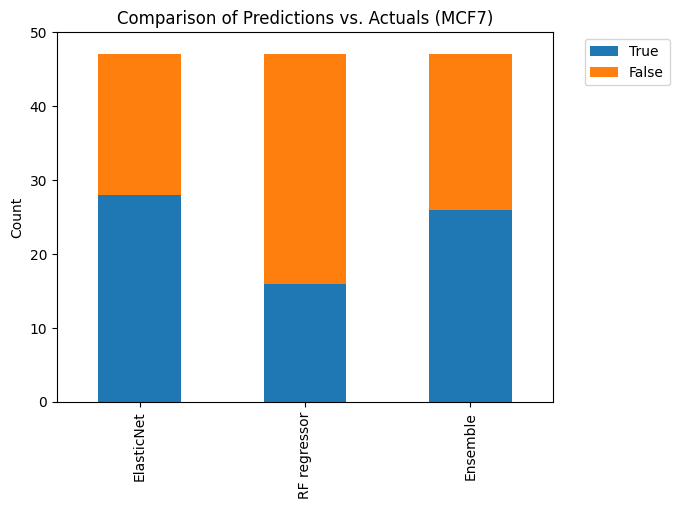

In [45]:
#MCF7
get_pred_vs_actual_comparison(df_elastic = mcf7_pred_elastic_filtered_mean,
                              df_rf = mcf7_pred_rf_filtered_mean,
                              df_ensemble = mcf7_pred_ensemble_filtered_mean,
                              df_lcms = mcf7_lcms_filtered_mean,
                              cell_line_name = 'MCF7')

Correctly predicted metabolites from Elastic Net: ['phosphocreatine', 'AMP', 'alanine', 'glutamate', 'hypoxanthine', 'taurine', 'adenine', 'proline', 'citrulline', 'creatine', 'threonine', 'UMP', 'phenylalanine']
Correctly predicted metabolites from Random forest regressor: ['phosphocreatine', 'serine', 'succinate/methylmalonate', 'alanine', 'fumarate/maleate/alpha-ketoisovalerate', 'glutamate', 'leucine', 'malate', 'ornithine', 'tyrosine', 'hypoxanthine', 'xanthine', 'valine', 'taurine', 'arginine', 'histidine', 'methionine', 'lysine', 'alpha-ketoglutarate', 'creatine', 'betaine', 'uridine', 'UMP', 'uracil', 'phenylalanine']
Correctly predicted metabolites from Ensemble: ['phosphocreatine', 'AMP', 'alanine', 'fumarate/maleate/alpha-ketoisovalerate', 'glutamate', 'asparagine', 'malate', 'hypoxanthine', 'glycine', 'arginine', 'homocysteine', 'citrulline', 'creatine', 'glutamine', 'threonine', 'UMP', 'phenylalanine']


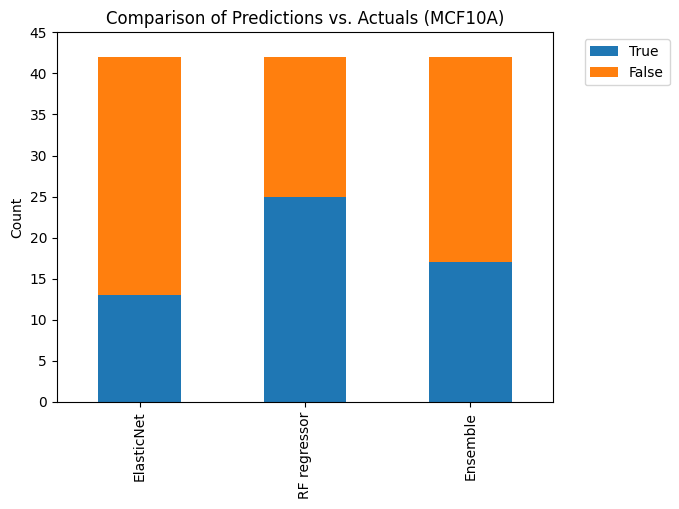

In [46]:
#MCF10A
get_pred_vs_actual_comparison(df_elastic = mcf10a_pred_elastic_filtered_mean,
                              df_rf = mcf10a_pred_rf_filtered_mean,
                              df_ensemble = mcf10a_pred_ensemble_filtered_mean,
                              df_lcms = mcf10a_lcms_filtered_mean,
                              cell_line_name = 'MCF10A')

In [68]:
mcf7_correct_metabolites = ['phosphocreatine', 'serine', 'aspartate', 'alanine', 'asparagine', 'leucine', 'glutathione reduced', 'allantoin', 'malate', 'ornithine', 'hypoxanthine', 'xanthine', 'glycine', 'homocysteine', 'adenine', 'histidine', 'proline', 'methionine', 'NAD', 'citrulline', 'glycodeoxycholate/glycochenodeoxycholate', 'GABA', 'glutamine', 'threonine', 'creatinine', 'uridine']

mcf10a_correct_metabolites = ['phosphocreatine', 'AMP', 'alanine', 'fumarate/maleate/alpha-ketoisovalerate', 'glutamate', 'asparagine', 'malate', 'hypoxanthine', 'glycine', 'arginine', 'homocysteine', 'citrulline', 'creatine', 'glutamine', 'threonine', 'UMP', 'phenylalanine']

In [48]:
!pip install matplotlib-venn

In [49]:
from matplotlib_venn import venn2

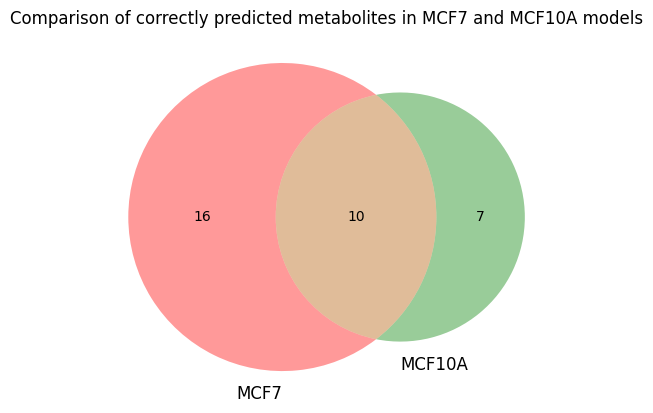

In [69]:
venn2([ set(mcf7_correct_metabolites), set(mcf10a_correct_metabolites)], set_labels=('MCF7', 'MCF10A'))
plt.title('Comparison of correctly predicted metabolites in MCF7 and MCF10A models')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/MCF10A_MCF7_common_correct_metabolites_venn.svg', bbox_inches = 'tight')
plt.show()

In [51]:
correct_common = list(set(mcf7_correct_metabolites).intersection(set(mcf10a_correct_metabolites)))
correct_common

['threonine', 'hypoxanthine', 'alanine', 'UMP', 'citrulline', 'creatine']

In [52]:
with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/MCF10A_MCF7_correct_common_metabolites.txt', 'w') as f:
    for item in correct_common:
      f.write("%s\n" % item)

#LCMS statistics and further plots

In [53]:
from scipy.stats import ttest_ind

In [54]:
def get_statistically_significant_metabolites(df, df_mean, pval_threshold):
  grouped = df.groupby('PI3K_status')
  mut = grouped.get_group('MUT').drop(columns=['PI3K_status'])
  wt = grouped.get_group('WT').drop(columns=['PI3K_status'])
  results = {}
  for col in mut.columns:
    t_stat, p_value = ttest_ind(mut[col], wt[col])
    results[col] = {'T-statistic': t_stat, 'P-value': p_value}
  results_df = pd.DataFrame(results).T
  results_df.index = mut.columns
  df_mean = df_mean.copy()
  df_mean.index.name = None
  res = pd.concat([df_mean, results_df], axis = 'columns')
  return res

In [55]:
mcf7_sig = get_statistically_significant_metabolites(df = mcf7_lcms_filtered, df_mean = mcf7_lcms_filtered_mean,  pval_threshold = 0.05)
mcf7_sig.head(2)

,MUT,WT,Higher_in_MUT,T-statistic,P-value
phosphocreatine,52197.437247,40512.775783,yes,1.441787,0.187339
serine,418974.144227,429159.303018,no,-0.299789,0.771980


In [56]:
mcf10a_sig = get_statistically_significant_metabolites(df = mcf10a_lcms_filtered, df_mean = mcf10a_lcms_filtered_mean,  pval_threshold = 0.05)
mcf10a_sig.head(2)

,MUT,WT,Higher_in_MUT,T-statistic,P-value
phosphocreatine,7840.352744,9049.163236,no,-0.453094,0.657951
serine,331504.583119,268726.297487,yes,1.595944,0.134514


In [57]:
def get_log2fc(df):
  df_res = df
  df_res['log2FC'] = np.log2(df_res['WT'] / df_res['MUT'])
  return   df_res

In [58]:
mf10a_log2fc = get_log2fc(mcf10a_sig)
mf7_log2fc = get_log2fc(mcf7_sig)

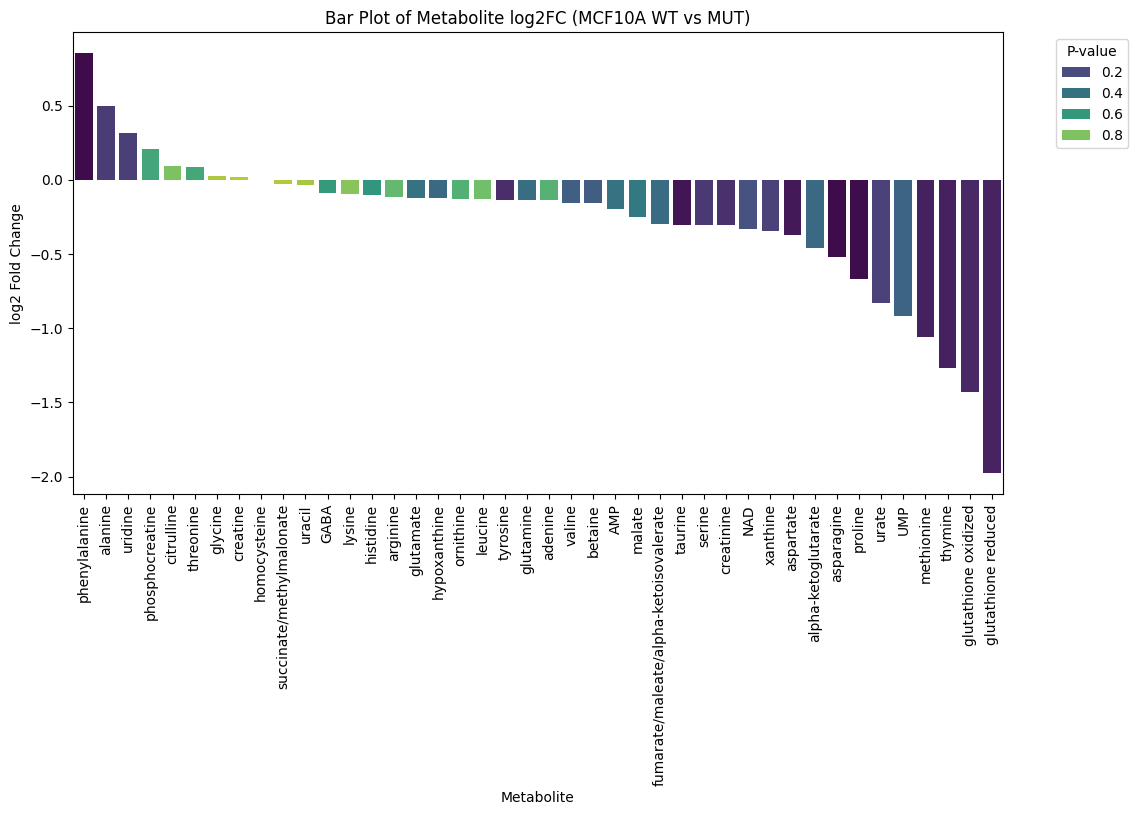

In [59]:
mf10a_log2fc_sorted = mf10a_log2fc.sort_values(by=['log2FC'], ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=mf10a_log2fc_sorted, x=mf10a_log2fc_sorted.index, y='log2FC',
            hue='P-value', palette='viridis', dodge=False)

# Customize the plot
plt.title('Bar Plot of Metabolite log2FC (MCF10A WT vs MUT)')
plt.xlabel('Metabolite')
plt.ylabel('log2 Fold Change')
plt.xticks(rotation=90)
plt.legend(title='P-value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

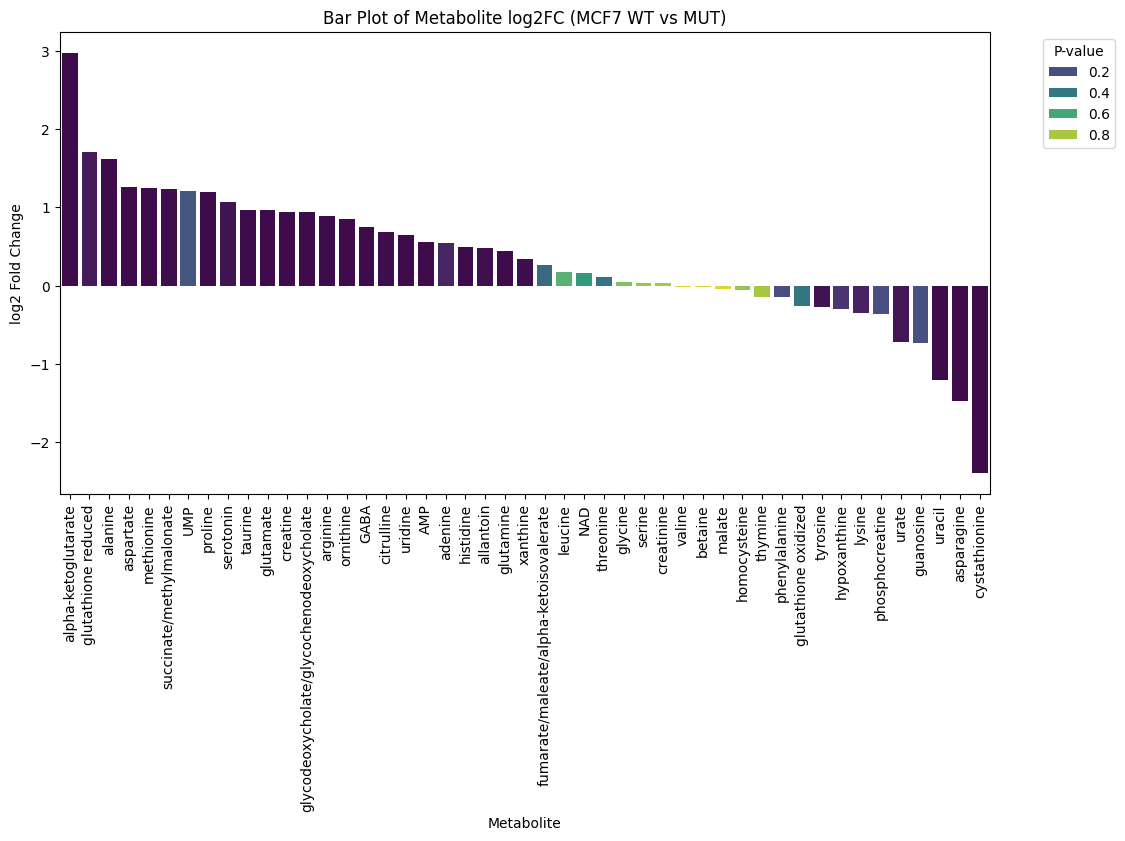

In [60]:
mf7_log2fc_sorted = mf7_log2fc.sort_values(by=['log2FC'], ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=mf7_log2fc_sorted, x=mf7_log2fc_sorted.index, y='log2FC',
            hue='P-value', palette='viridis', dodge=False)

plt.title('Bar Plot of Metabolite log2FC (MCF7 WT vs MUT)')
plt.xlabel('Metabolite')
plt.ylabel('log2 Fold Change')
plt.xticks(rotation=90)
plt.legend(title='P-value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [61]:
combined = pd.concat([mf7_log2fc_sorted.rename(columns = {'P-value' : 'mcf7_pval', 'log2FC' : 'mcf7_log2FC'})[['mcf7_pval', 'mcf7_log2FC']],
                      mf10a_log2fc_sorted.rename(columns = {'P-value' : 'mcf10a_pval', 'log2FC' : 'mcf10a_log2FC'})[['mcf10a_pval', 'mcf10a_log2FC']]],
                      axis = 'columns')
combined

,mcf7_pval,mcf7_log2FC,mcf10a_pval,mcf10a_log2FC
alpha-ketoglutarate,6.365599e-05,2.971516,0.347061,-0.456910
glutathione reduced,3.830600e-02,1.705708,0.066683,-1.976793
alanine,1.230378e-04,1.613954,0.144924,0.497001
aspartate,2.374887e-06,1.255152,0.039034,-0.372168
methionine,1.958049e-03,1.246639,0.059605,-1.059673
succinate/methylmalonate,7.609295e-03,1.232117,0.914720,-0.028097
UMP,2.224696e-01,1.205380,0.325606,-0.914293
proline,1.989364e-06,1.190863,0.005570,-0.668644
serotonin,2.298068e-02,1.067175,NaN,NaN
taurine,1.216436e-05,0.971958,0.028058,-0.302115


In [62]:
combined = combined.dropna()
combined = combined[(combined['mcf7_pval'] < 0.05) & (combined['mcf10a_pval'] < 0.05)]
combined

,mcf7_pval,mcf7_log2FC,mcf10a_pval,mcf10a_log2FC
aspartate,2.374887e-06,1.255152,0.039034,-0.372168
proline,1.989364e-06,1.190863,0.005570,-0.668644
taurine,1.216436e-05,0.971958,0.028058,-0.302115
asparagine,7.230879e-07,-1.472887,0.000264,-0.517944


In [63]:
combined_heatmap_data = combined.rename(columns = {'mcf7_log2FC': 'MCF7', 'mcf10a_log2FC': 'MCF10A'})[['MCF7', 'MCF10A']]
combined_heatmap_data

,MCF7,MCF10A
aspartate,1.255152,-0.372168
proline,1.190863,-0.668644
taurine,0.971958,-0.302115
asparagine,-1.472887,-0.517944


<Axes: title={'center': 'log2FC (WT vs MUT) of altered metabolites (LCMS, p-value < 0.05)'}>

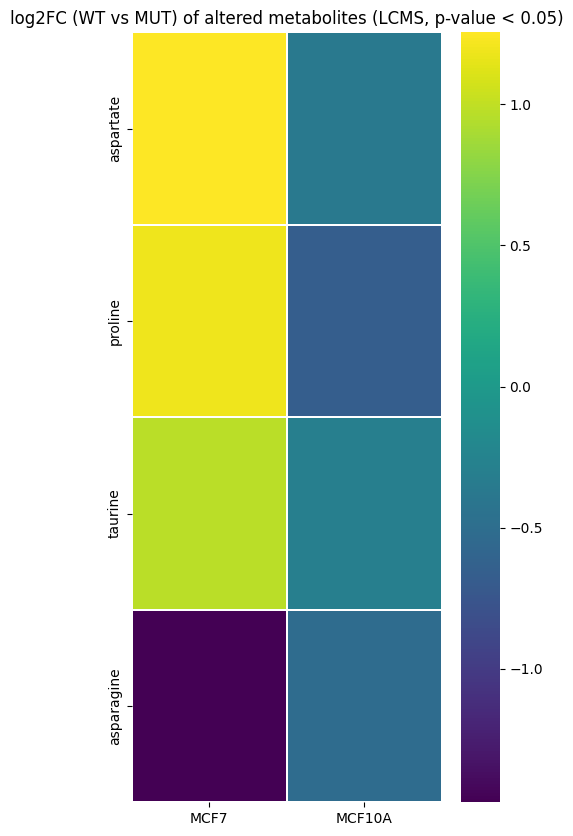

In [64]:
plt.figure(figsize=(5, 10))
plt.title('log2FC (WT vs MUT) of altered metabolites (LCMS, p-value < 0.05)')
sns.heatmap(data = combined_heatmap_data, linewidths = 0.01, cmap = 'viridis')

In [65]:
combination = list(set(correct_common).intersection(set(list(combined_heatmap_data.index))))
(len(combination) * 100/ len(correct_common))

0.0

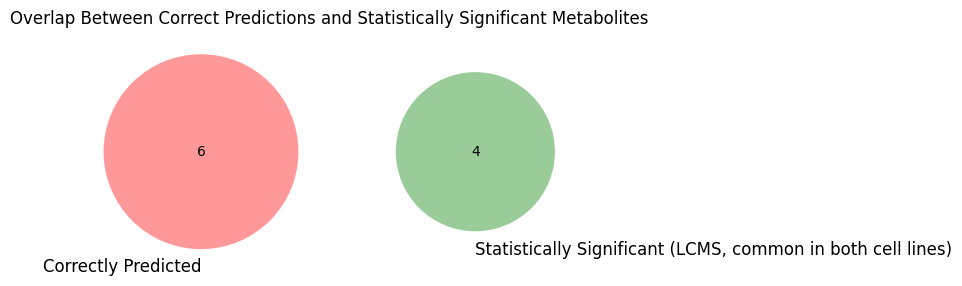

In [66]:
set1 = set(correct_common)
set2 = set(list(combined_heatmap_data.index))

venn2([set1, set2], set_labels=('Correctly Predicted', 'Statistically Significant (LCMS, common in both cell lines)'))
plt.title('Overlap Between Correct Predictions and Statistically Significant Metabolites')
plt.show()

Correctly predicted metabolites from Elastic Net: []
Correctly predicted metabolites from Random forest regressor: []
Correctly predicted metabolites from Ensemble: []


ValueError: could not convert string to float: '−0.06'

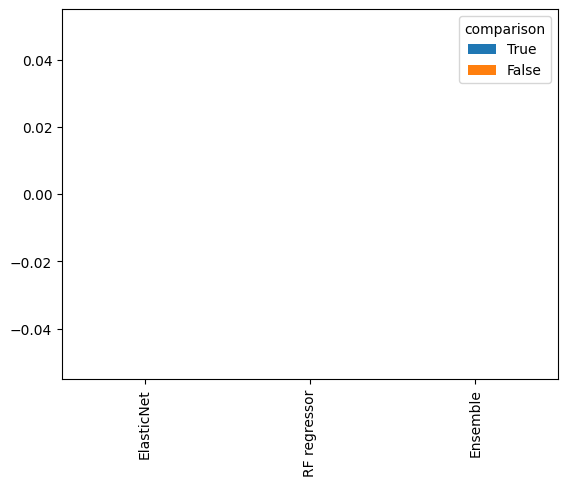

In [67]:
#MCF7
get_pred_vs_actual_comparison(df_elastic = mcf7_pred_elastic_filtered_mean.loc[combination],
                              df_rf = mcf7_pred_rf_filtered_mean.loc[combination],
                              df_ensemble = mcf7_pred_ensemble_filtered_mean.loc[combination],
                              df_lcms = mcf7_lcms_filtered_mean.loc[combination],
                              cell_line_name = 'MCF7_stat_sig')

In [ ]:
#MCF10A
get_pred_vs_actual_comparison(df_elastic = mcf10a_pred_elastic_filtered_mean.loc[combination],
                              df_rf = mcf10a_pred_rf_filtered_mean.loc[combination],
                              df_ensemble = mcf10a_pred_ensemble_filtered_mean.loc[combination],
                              df_lcms = mcf10a_lcms_filtered_mean.loc[combination],
                              cell_line_name = 'MCF10A_stat_sig')